# 06 - Native Metrics vs. Intent-Tagged Delivery Events

## Objetivo
Comparar os contadores nativos de `sequence.utils.metrics`
(`eg_success`/`ep_success`/`es_success`, chaveados por nó) com os eventos
`DELIVERY` tagueados por `intent_id`, e demonstrar empiricamente **por que**
os contadores nativos não bastam como prova de satisfação de um intent
específico - reproduzindo, de forma controlada, a mesma contaminação
cross-run encontrada durante a construção de
`03_sequence_purification.ipynb`.

## Conceitos
- `sequence.utils.metrics` é desabilitado por padrão; `SequenceExecutor`
  chama `metrics.enable([...])` para os tipos de evento que a arquitetura
  usa (`EG_SUCCESS`/`FAILURE`, `EP_SUCCESS`/`FAILURE`, `ES_SUCCESS`/`FAILURE`,
  `DELIVERY`).
- `CounterMetric` (`eg`/`ep`/`es`) e `DeliveryTimeMetric` agregam eventos
  filtrando por **nome do nó** (`owner_name`) - nenhum deles sabe o que é
  um "intent". `EventTypes.DELIVERY` é o único tipo de evento tagueado com
  `intent_id`, e essa tag é adicionada por `IntentRequestApp`
  (`execution.sequence_executor`), não pelo núcleo do SeQUeNCe.
- Duas *callbacks* reais conectam o SeQUeNCe ao `ibqn`:
  `IntentRequestApp.get_reservation_result` (aceitação/rejeição da reserva
  -> `IntentStatus.ACTIVE`/`FAILED`) e `IntentRequestApp.get_memory`
  (cada memória que chega a `ENTANGLED`/`PURIFIED` e casa com a reserva ->
  incrementa `_delivered_pairs` e grava um `DELIVERY`).
- `sequence.utils.metrics.storage` é um singleton de processo
  (`docs/sequence_code_analysis.md`, seção 4.1): se duas simulações rodam
  em sequência no mesmo kernel sem `metrics.configure()` entre elas, os
  contadores nativos por nó se acumulam - foi exatamente isso que apareceu
  (e foi corrigido) em `03_sequence_purification.ipynb`. Este notebook
  reproduz esse efeito de propósito, em um cenário simples e controlado,
  para tornar a limitação concreta em vez de apenas descrita em texto.


## Configuração


In [1]:
from sequence.utils import metrics
from ibqn.demos.topologies import two_node_spec
from ibqn.network.sequence_adapter import SequenceAdapter
from ibqn.execution.sequence_executor import SequenceExecutor
from ibqn.intent.repository import IntentRepository
from ibqn.intent.models import (
    EntanglementIntent, IntentEndpoints, IntentRequirements, IntentValidation, SuccessCondition,
)
from ibqn.assurance.telemetry import collect_intent_evidence

SEED = 0
REQUESTED_PAIRS = 10
MIN_FIDELITY = 0.65

spec = two_node_spec(memories=REQUESTED_PAIRS, distance_m=1000, attenuation_db_per_m=1e-4)


def make_intent(intent_id: str) -> EntanglementIntent:
    return EntanglementIntent(
        id=intent_id,
        endpoints=IntentEndpoints(source="a", destination="b"),
        requirements=IntentRequirements(
            min_fidelity=MIN_FIDELITY, min_throughput=1, max_latency=1.0,
            requested_pairs=REQUESTED_PAIRS, start_time=0.02, duration=0.1,
        ),
        validation=IntentValidation(
            metrics=["delivered_pairs"],
            success_conditions=[SuccessCondition(metric="delivered_pairs", operator=">=", expected=REQUESTED_PAIRS)],
        ),
    )


def run(intent, *, reset_metrics_first: bool):
    if reset_metrics_first:
        metrics.configure()  # fresh storage: this run's native counters start at zero
    adapter = SequenceAdapter(spec, seed=SEED)
    repository = IntentRepository()
    executor = SequenceExecutor(adapter, repository)
    executor.submit(intent)
    executor.run()
    native = metrics.collect_trial_metrics(intent.endpoints.source)
    evidence = collect_intent_evidence(intent)  # collected now: a later un-reset run would not erase this
    return native, evidence


## Execução

Três rodadas, todas sobre a mesma topologia/seed (portanto deterministicamente
idênticas):

1. `intent_1`, com reset - linha de base isolada.
2. `intent_2`, **sem** reset logo em seguida - reproduz de propósito a
   contaminação (os contadores nativos por nó ainda carregam os eventos de
   `intent_1`, já que os dois intents reusam os nomes de nó `a`/`b`).
3. `intent_2` de novo, agora com reset - controle isolado, para comparação
   quantitativa com a rodada 2.


In [2]:
intent_1 = make_intent("intent-metrics-demo-1")
intent_2 = make_intent("intent-metrics-demo-2")

native_1, evidence_1 = run(intent_1, reset_metrics_first=True)
native_2_contaminated, evidence_2_contaminated = run(intent_2, reset_metrics_first=False)
native_2_isolated, evidence_2_isolated = run(intent_2, reset_metrics_first=True)


2026-10-02 15:03:24,880 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'requested_pairs' -> 'reserved_memory_slots' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:24,886 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'start_time' -> 'start_time_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:24,887 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'duration' -> 'duration_s' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:24,889 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'requested_pairs' -> 'reserved_memory_slots' (see docs/intent_resource_semantics.md)


2026-10-02 15:03:24,891 INFO     ibqn.ibqn.intent.models intent_id=- - IntentRequirements: migrating legacy field 'start_time' -> 'start_time_s' (see docs/intent_resource_semantics.md)


...

2026-10-02 15:03:29,394 INFO     ibqn.ibqn.intent.repository intent_id=intent-metrics-demo-2 - intent transitioned to PLANNED (trivial pass-through plan)


2026-10-02 15:03:29,396 INFO     ibqn.ibqn.intent.repository intent_id=intent-metrics-demo-2 - intent transitioned to DEPLOYING (submitting reservation to NetworkManager)


2026-10-02 15:03:29,397 INFO     ibqn.ibqn.execution.sequence_executor intent_id=intent-metrics-demo-2 - submitting reservation a -> b, reserved_memory_slots=10, min_fidelity=0.650, purification_mode=until_target


2026-10-02 15:03:29,398 INFO     ibqn.ibqn.network.sequence_adapter intent_id=- - running simulation, stop_time=0.100s


2026-10-02 15:03:29,400 INFO     ibqn.ibqn.intent.repository intent_id=intent-metrics-demo-2 - intent transitioned to ACTIVE (reservation approved)


## Resultados


In [3]:
import pandas as pd

comparison_df = pd.DataFrame([
    {
        "run": "intent_1 (reset before)",
        "eg_success (native, per-node)": native_1["eg_success"],
        "delivered_pairs (DELIVERY, per-intent)": len(evidence_1.delivered_pairs),
    },
    {
        "run": "intent_2 (NOT reset - contaminated)",
        "eg_success (native, per-node)": native_2_contaminated["eg_success"],
        "delivered_pairs (DELIVERY, per-intent)": len(evidence_2_contaminated.delivered_pairs),
    },
    {
        "run": "intent_2 (reset before - isolated control)",
        "eg_success (native, per-node)": native_2_isolated["eg_success"],
        "delivered_pairs (DELIVERY, per-intent)": len(evidence_2_isolated.delivered_pairs),
    },
])
comparison_df


,run,"eg_success (native, per-node)","delivered_pairs (DELIVERY, per-intent)"
0,intent_1 (reset before),389,389
1,intent_2 (NOT reset - contaminated),778,389
2,intent_2 (reset before - isolated control),389,389


In [4]:
assert native_2_contaminated["eg_success"] == native_1["eg_success"] + native_2_isolated["eg_success"], (
    "the contaminated run's native counter should equal the sum of both runs: it is the SAME "
    "process-wide storage, keyed only by node name 'a', with no notion of which intent asked for what"
)
assert len(evidence_2_contaminated.delivered_pairs) == len(evidence_2_isolated.delivered_pairs), (
    "delivered_pairs is filtered by intent_id, so it must be identical whether or not the native "
    "counters were contaminated by an unrelated earlier run"
)
print("Confirmed: native per-node counters conflate across runs; intent-tagged DELIVERY evidence does not.")


Confirmed: native per-node counters conflate across runs; intent-tagged DELIVERY evidence does not.


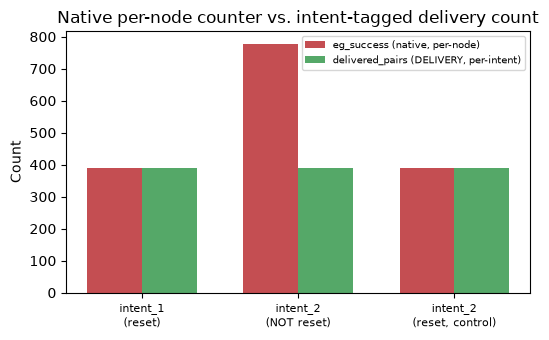

In [5]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5.5, 3.5))
labels = ["intent_1\n(reset)", "intent_2\n(NOT reset)", "intent_2\n(reset, control)"]
eg_values = [native_1["eg_success"], native_2_contaminated["eg_success"], native_2_isolated["eg_success"]]
delivered_values = [len(evidence_1.delivered_pairs), len(evidence_2_contaminated.delivered_pairs), len(evidence_2_isolated.delivered_pairs)]

x = range(len(labels))
width = 0.35
ax.bar([i - width / 2 for i in x], eg_values, width, label="eg_success (native, per-node)", color="#C44E52")
ax.bar([i + width / 2 for i in x], delivered_values, width, label="delivered_pairs (DELIVERY, per-intent)", color="#55A868")
ax.set_xticks(list(x))
ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Count")
ax.set_title("Native per-node counter vs. intent-tagged delivery count")
ax.legend(fontsize=7)
fig.tight_layout()
plt.show()


## Interpretação
`eg_success` da rodada 2 sem reset é exatamente a soma das duas rodadas
isoladas - porque `sequence.utils.metrics.storage` é um único registro de
processo chaveado por nome de nó, e `intent_1`/`intent_2` reusam os
mesmos nós `a`/`b`. Já `delivered_pairs`, construído exclusivamente a
partir de eventos `DELIVERY` filtrados por `intent_id`
(`ibqn.assurance.telemetry.collect_intent_evidence`), permanece idêntico
entre a rodada contaminada e o controle isolado: a tag de intent
sobrevive à contaminação do contador nativo porque vive num campo
separado do mesmo registro, não no `owner_name` usado para agregação.
Esta é a razão arquitetural pela qual `ibqn.assurance` nunca usa
`eg_success`/`ep_success`/`es_success` como prova de satisfação de um
intent - eles são úteis apenas como contexto diagnóstico *dentro de uma
única rodada isolada*.

## Limitações
- Este notebook reproduz a contaminação de propósito, em um cenário
  controlado de dois nós - não é uma falha da arquitetura de produção
  (`ibqn.experiments.runner.run_scenario` já chama `metrics.configure()`
  no início de cada rodada); é uma demonstração do que aconteceria sem
  essa chamada.
- `DeliveryTimeMetric`/`FidelityMetric` nativos também filtram por
  `owner_name`, não por `intent_id` - sofrem da mesma limitação que
  `eg_success`/`ep_success`/`es_success` demonstrada acima, embora não
  testados individualmente aqui.

## Conclusão
Diferença entre métricas nativas por nó e evidência por intent
demonstrada empiricamente, incluindo o mecanismo exato de contaminação
(`storage` de processo compartilhado) e a razão pela qual apenas eventos
`DELIVERY` tagueados por `intent_id` são usados por `ibqn.assurance`.
